# Model Sapması Avı — iki dönem neden bozuk

**Konum:** `experiments/notebooks/05_crisis_analysis/02_model_bias_investigation.ipynb`
**Tarih:** 18 Ağustos 2026
**Önce oku:** `01_counterfactual_model.ipynb`

## Soru

Kontrafaktüel aleti kurulduktan sonra iki dönemde sistematik sapma çıktı:

| Dönem | Kalıntı | Yön |
|---|---|---|
| Ocak – Mart 2022 | −$9 … −$23 | model fiyatı **fazla** tahmin ediyor |
| Ekim 2022 – Mart 2023 | +$9 … +$19 | model fiyatı **eksik** tahmin ediyor |

Bunlar olay mı, yoksa modelin körlüğü mü? Cevap kritik: ikisi de analiz etmek
istediğimiz olayların yoğunlaştığı dönemler. Sapma bilinmeden yapılan her ölçüm
o dönemlerde şişik veya eksik çıkar.

## Sonuç (özet)

**Model körlüğü.** Sebep tek bir değişken: modele beslediğimiz gaz maliyeti
(`natural_gas_grf_try`, EPİAŞ piyasa referans fiyatı), santrallerin fiilen ödediği
**BOTAŞ elektrik üretim tarifesi** değil. Normal aylarda ikisi yakın; iki dönemde
ayrışıyorlar ve kalıntı tam o iki dönemde bozuluyor. Ayrıntı:
`03_gas_tariff_discovery.ipynb`.

Bu notebook oraya nasıl varıldığını, **elenen hipotezler dahil** kaydeder.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# Analiz modelinin birincil sürümü. crisis_cf_v2/v3/v4 karşılaştırma içindir,
# analizde kullanma (gerekçe: 02_model_bias_investigation.ipynb §7).
VARIANT = 'fundamental'
MODEL   = 'crisis_cf_v1'

def cf(model=None, variant=None, where=''):
    """gold.crisis_counterfactual okuma yardımcısı — saat indeksli, tz-aware."""
    q = text(f"""
        SELECT ts, actual_usd, counterfactual_usd, residual_usd, at_cap, is_lower_bound, fold_id
        FROM gold.crisis_counterfactual
        WHERE variant = :v AND model_name = :m {where}
        ORDER BY ts
    """)
    d = pd.read_sql(q, engine, params={'v': variant or VARIANT, 'm': model or MODEL})
    d['ts'] = pd.to_datetime(d['ts'], utc=True).dt.tz_convert('Europe/Istanbul')
    for c in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
        d[c] = d[c].astype(float)
    return d.set_index('ts')

print('bağlantı hazır')

bağlantı hazır


## 1. Sapmanın keşfi ve şekli — düz mü, tepeli mi

Ayırt edici test: bir **olay** birkaç günde tepe yapar, medyanı kıpırdatmaz.
Bir **yapısal körlük** dağılımın tamamını kaydırır, medyan ile ortalama birlikte gider.

In [2]:
d = cf(); unc = d[~d.at_cap]

aylik = unc.resample('MS').agg(
    n=('residual_usd', 'size'), ort=('residual_usd', 'mean'), med=('residual_usd', 'median'),
    poz_pct=('residual_usd', lambda s: 100 * (s > 0).mean()),
)
display(aylik.loc['2021-10':'2023-06'].round(1))

sapmali = unc.loc['2022-10':'2023-03']
referans = unc.loc['2024-01':'2025-12']
for ad, s in [('2022-10 … 2023-03', sapmali), ('2024-2025 referans', referans)]:
    print('%-20s  poz.saat %%%2.0f   ort %+6.1f   med %+6.1f   IQR [%+.1f, %+.1f]' % (
        ad, 100 * (s.residual_usd > 0).mean(), s.residual_usd.mean(),
        s.residual_usd.median(), *s.residual_usd.quantile([.25, .75])))

,n,ort,med,poz_pct
ts,,,,
2021-10-01 00:00:00+03:00,576,6.4,4.2,61.6
2021-11-01 00:00:00+03:00,579,0.0,-0.5,47.8
2021-12-01 00:00:00+03:00,533,-7.2,-7.9,19.9
2022-01-01 00:00:00+03:00,441,-13.5,-14.0,18.6
2022-02-01 00:00:00+03:00,301,-3.7,-5.8,40.2
2022-03-01 00:00:00+03:00,258,-8.9,-10.0,20.2
2022-04-01 00:00:00+03:00,610,8.7,10.7,74.4
2022-05-01 00:00:00+03:00,639,1.2,-1.8,46.9
2022-06-01 00:00:00+03:00,710,2.3,0.7,53.1


2022-10 … 2023-03     poz.saat %70   ort  +12.7   med  +14.3   IQR [-4.5, +30.9]
2024-2025 referans    poz.saat %50   ort   -0.3   med   +0.0   IQR [-5.0, +4.5]


### 📌 Bölüm 1 Analiz Notları

- Ekim 2022 – Mart 2023'te saatlerin **%71'i** pozitif kalıntılı (normalde %50).
- Ortalama +$13,1, medyan **+$14,9** — ikisi birlikte kaymış.
- **Bu bir olay imzası değil.** Dağılımın tamamı yukarı ötelenmiş: yapısal körlük.

## 2. Elenen hipotez A — sansür seçimi

Hipotez: çok sansürlenen bir ayda sansürsüz kalan saatler *seçilmiş* bir örneklemdir
(geceler, hafta sonları — yani ucuz saatler). Model ayın fundamentallerine bakıp yüksek
fiyat bekler, ama karşılaştırdığı saatler ayın en ucuzlarıdır → negatif kalıntı.

Doğruysa sapma **gece saatlerinde yoğunlaşmalı**.

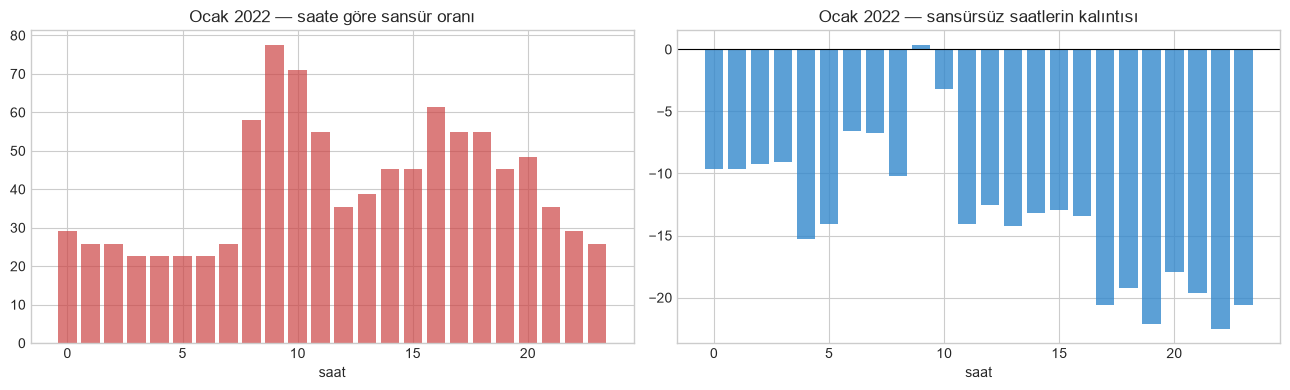

negatif kalıntılı saat: 23 / 24
gece (0-6) ort: -10.5   akşam zirvesi (17-23) ort: -20.4


In [3]:
ay = d.loc['2022-01']
prof = pd.DataFrame({
    'sansur_pct': 100 * ay.groupby(ay.index.hour).at_cap.mean(),
    'n_sansursuz': ay[~ay.at_cap].groupby(ay[~ay.at_cap].index.hour).size(),
    'kalinti': ay[~ay.at_cap].groupby(ay[~ay.at_cap].index.hour).residual_usd.mean(),
})
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(prof.index, prof.sansur_pct, color='#c44', alpha=.7)
ax[0].set_title('Ocak 2022 — saate göre sansür oranı'); ax[0].set_xlabel('saat')
ax[1].bar(prof.index, prof.kalinti, color='#38c', alpha=.8)
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_title('Ocak 2022 — sansürsüz saatlerin kalıntısı'); ax[1].set_xlabel('saat')
plt.tight_layout(); plt.show()

print('negatif kalıntılı saat: %d / 24' % (prof.kalinti < 0).sum())
print('gece (0-6) ort: %+.1f   akşam zirvesi (17-23) ort: %+.1f'
      % (prof.kalinti.loc[0:6].mean(), prof.kalinti.loc[17:23].mean()))

### 📌 Bölüm 2 Analiz Notları — hipotez ÇÜRÜDÜ

- Kalıntı **24 saatin 23'ünde negatif**, ve en büyük sapma gecede değil
  **akşam zirvesinde** (17-23 arası −$18 … −$22).
- Seçilmiş ucuz saatler olsaydı sapma gecelerde toplanırdı. Toplanmıyor —
  ay bütünüyle aşağı kaymış. Sebep örneklem seçimi değil.

## 3. Elenen hipotez B — kur gürültüsü

Hedef `mcp_price_usd`. Aralık 2021'de kurda büyük hareket var (KKM). Ocak 2022'nin
USD dönüşümü gürültülüyse kalıntı da bozulur.

,min,max,mean,std
entry_date,,,,
2021-11-01,9.52,13.14,10.73,1.14
2021-12-01,11.19,17.78,13.74,1.67
2022-01-01,13.28,13.91,13.56,0.19
2022-02-01,13.38,14.38,13.64,0.19
2022-03-01,13.93,14.95,14.64,0.27


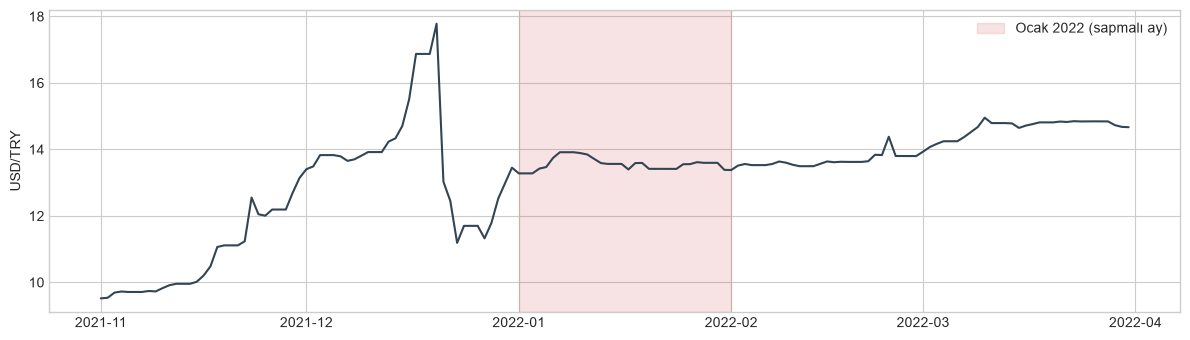

In [4]:
fx = pd.read_sql(text("""
    SELECT entry_date, usd_try FROM raw_macro_daily
    WHERE entry_date >= '2021-11-01' AND entry_date < '2022-04-01' ORDER BY entry_date
"""), engine).set_index('entry_date')
fx.index = pd.to_datetime(fx.index)
display(fx.usd_try.resample('MS').agg(['min', 'max', 'mean', 'std']).round(2))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(fx.index, fx.usd_try, color='#345')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-02-01'), color='#c44', alpha=.15,
           label='Ocak 2022 (sapmalı ay)')
ax.set_ylabel('USD/TRY'); ax.legend(); plt.tight_layout(); plt.show()

### 📌 Bölüm 3 Analiz Notları — hipotez ÇÜRÜDÜ

- Aralık 2021'de hareket gerçek (17,78 → 11,19, KKM açıklaması).
- Ama **Ocak 2022 kuru durgun: std 0,19**, aralık 13,28–13,91. Dönüşüm gürültüsü değil.

## 4. Modele sormak — neye bakıp yüksek tahmin ediyor

Ocak 2022'yi hiç görmemiş bir model eğitip feature önemlerine, ve Ocak 2022'nin
o feature'lardaki konumuna bakalım. **Bu hücre model eğitir (~30 sn).**

In [5]:
from src.crisis.analysis_model import (
    load_analysis_data, build_analysis_features, get_analysis_feature_columns,
    prepare_model_frame, fit_counterfactual, uncensored_mask,
)

raw = load_analysis_data()
feat = build_analysis_features(raw)
cols = get_analysis_feature_columns('fundamental', feat)   # fuel_dynamics=None → v1
m = prepare_model_frame(feat, cols)

pencere = (m.index >= '2022-01-15') & (m.index < '2022-02-11')
tampon  = (m.index >= '2022-01-07') & (m.index < '2022-02-19')
egitim = m[(~tampon) & uncensored_mask(m)]
fc = fit_counterfactual(egitim, cols)

imp = pd.Series(fc.model.feature_importances_, index=cols).sort_values(ascending=False)
top = imp.head(12)
tablo = pd.DataFrame({
    'onem': top,
    'ocak22': m.loc[pencere, top.index].mean(),
    'egitim_ort': egitim[top.index].mean(),
    'ocak22_yuzdelik': [100 * (egitim[c] < m.loc[pencere, c].mean()).mean() for c in top.index],
})
display(tablo.round(2))
print('yuzdelik = Ocak 2022 ortalamasının eğitim dağılımındaki yeri')

/Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/src/crisis/analysis_model.py:288: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feat[f"{name}_usd_chg_{days}d"] = src.pct_change(hours, fill_method=None).astype(float)
/Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/src/crisis/analysis_model.py:286: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feat[f"{name}_usd_ma_{days}d"] = ma
/Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/src/crisis/analysis_model.py:287: PerformanceWarn

,onem,ocak22,egitim_ort,ocak22_yuzdelik
hour,971,11.50,10.83,53.96
kgup_gas_lag0,961,8428.72,6873.47,62.38
kgup_coal_lag0,790,12180.61,11256.77,52.59
cos_hour,691,-0.00,0.00,49.03
days_to_nearest_holiday,689,338.00,132.46,82.02
cos_doy,639,0.88,-0.06,86.51
actual_gen_lag0,636,37693.83,35153.00,68.07
usd_try_lag0,611,13.52,27.19,17.06
sin_doy,556,0.46,0.06,61.64
predicted_wind_lag0,541,4384.34,4288.51,55.43


yuzdelik = Ocak 2022 ortalamasının eğitim dağılımındaki yeri


### 📌 Bölüm 4 Analiz Notları

- Belirleyici feature: **`natural_gas_grf_lag_48` = 757 vs eğitim ortalaması 446**,
  yani eğitim dağılımının **%88,7'lik diliminde**.
- Model "gaz maliyeti çok yüksek → fiyat yüksek olmalı" diyor ve ~$105 tahmin ediyor.
- Bu eşleşmeyi öğrendiği yer 2022'nin son çeyreği — ama o dönemde tavan $258 iken
  Ocak 2022'de $99'du. Yani model doğru ilişkiyi yanlış rejime uyguluyor.
- İpucu buradan çıktı: **sorun modelin varsayımı değil, ona verdiğimiz maliyet serisi.**

## 5. Gaz maliyeti ile kalıntının ilişkisi

Eğer sorun maliyet serisiyse, kalıntı gazın **değişim hızıyla** ilişkili olmalı:
gaz hızla düşerken model fiyatı düşük tahmin eder (pozitif kalıntı), hızla yükselirken
yüksek tahmin eder (negatif kalıntı).

kalıntı ↔ GRF 3 aylık değişimi korelasyonu: -0.429  (n=65 ay)


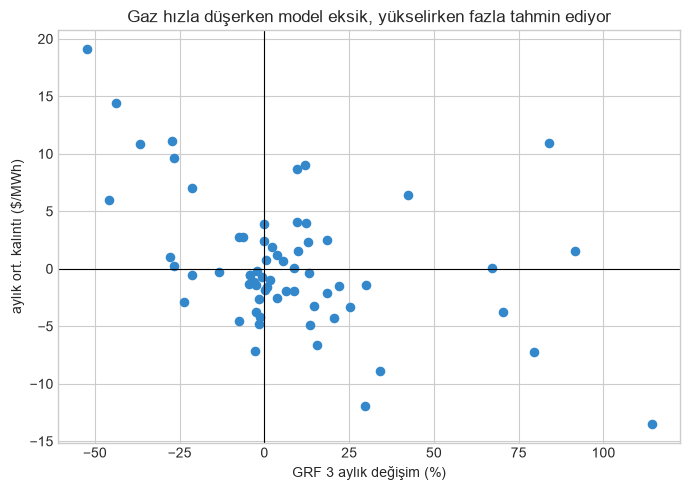

In [6]:
g = pd.read_sql(text('SELECT entry_date, gas_reference_price_try FROM raw_natural_gas_daily'), engine)
g.index = pd.to_datetime(g.entry_date)
fxd = pd.read_sql(text('SELECT entry_date, usd_try FROM raw_macro_daily'), engine)
fxd.index = pd.to_datetime(fxd.entry_date)
grf_usd = (g.gas_reference_price_try.resample('MS').mean() / fxd.usd_try.resample('MS').mean()).dropna()
grf_usd.index = grf_usd.index.tz_localize('Europe/Istanbul')

df = pd.DataFrame({'kalinti': unc.resample('MS').residual_usd.mean(), 'grf_usd': grf_usd}).dropna()
df['grf_3ay_degisim_pct'] = 100 * df.grf_usd.pct_change(3)
df = df.dropna()

print('kalıntı ↔ GRF 3 aylık değişimi korelasyonu: %.3f  (n=%d ay)'
      % (df.kalinti.corr(df.grf_3ay_degisim_pct), len(df)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df.grf_3ay_degisim_pct, df.kalinti, c='#38c', s=35)
ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('GRF 3 aylık değişim (%)'); ax.set_ylabel('aylık ort. kalıntı ($/MWh)')
ax.set_title('Gaz hızla düşerken model eksik, yükselirken fazla tahmin ediyor')
plt.tight_layout(); plt.show()

### 📌 Bölüm 5 Analiz Notları

- Korelasyon **−0,43** (65 ay). İki yönde de çalışıyor.
- İlk yorumum "geçiş gecikmesi" idi — model gaz maliyetinin fiyata anında geçtiğini
  varsayıyor sandım. Kısmen doğru ama **eksik**: asıl mesele geciken şeyin ne olduğu.
  Cevap `03_gas_tariff_discovery.ipynb`'de: geciken, BOTAŞ tarifesinin kendisi.

## 6. Üç düzeltme denemesi — ve hepsinin başarısızlığı

Modele yakıt maliyetinin geçmişi eklendi, üç farklı formülasyonla:

| Sürüm | Yakıt sütunları |
|---|---|
| `crisis_cf_v1` | yok |
| `crisis_cf_v2` | mutlak seviye (`gas_usd_ma_30d`, `ma_90d`, $/MWh) |
| `crisis_cf_v3` | sadece 7 günlük pencere |
| `crisis_cf_v4` | uzun pencere ama birimsiz (oran + % değişim) |

Test iki koşullu: **(a)** Eki22–Mar23 sapması sıfıra yaklaşsın, **(b)** İran sinyali
(+$16,5) yerinde kalsın. Bir sürümün kabul edilmesi için ikisi birden gerekir.

In [7]:
rows = []
modeller = ['crisis_cf_v1', 'crisis_cf_v2', 'crisis_cf_v3', 'crisis_cf_v4']
tumu = {mm: cf(model=mm) for mm in modeller}
ortak = set.intersection(*[set(v.index) for v in tumu.values()])

for mm, v in tumu.items():
    v = v[v.index.isin(ortak)]
    u = v[~v.at_cap]
    ay_ = u.resample('MS').residual_usd.mean()
    rows.append(dict(
        model=mm, MAE=u.residual_usd.abs().mean(), BIAS=u.residual_usd.mean(),
        ay_sapma=ay_.abs().mean(), ay_gt10=int((ay_.abs() > 10).sum()),
        eki22_mar23=u.loc['2022-10':'2023-03'].residual_usd.mean(),
        iran_kesinti=v.loc['2022-01-21':'2022-01-31'].residual_usd.mean(),
        iran_tavan_sonrasi=v.loc['2022-02-01':'2022-02-10'].residual_usd.mean(),
    ))
display(pd.DataFrame(rows).set_index('model').round(2))
print('ortak kapsam: %d saat' % len(ortak))

,MAE,BIAS,ay_sapma,ay_gt10,eki22_mar23,iran_kesinti,iran_tavan_sonrasi
model,,,,,,,
crisis_cf_v1,10.29,0.61,4.11,7,12.74,4.02,16.49
crisis_cf_v2,10.34,0.28,4.29,8,3.57,-2.13,0.17
crisis_cf_v3,10.28,0.60,4.05,5,11.17,1.02,16.48
crisis_cf_v4,10.57,0.82,4.53,10,11.15,10.62,18.57


ortak kapsam: 47072 saat


### 📌 Bölüm 6 Analiz Notları — üçü de reddedildi

- **v2** koşul (a)'yı sağlıyor (+12,74 → +3,57) ama **(b)'yi çökertiyor: İran sinyali
  +$16,5 → +$0,2.** 90 günlük ortalama "anlık maliyet"ten çok "hangi dönemdeyiz" demek;
  dönemi tanıyan model o dönemde ne olduysa onu da açıklıyor. `autoregressive`
  varyanttaki hatanın aynısı, dünkü fiyat yerine gaz maliyeti üzerinden.
- **v3** v1'in aynısı (ortalama fark $0,55). Gaz günden güne çok yavaş hareket ettiği
  için 7 günlük ortalama lag0'a yeni bilgi katmıyor.
- **v4** hiçbir şeyi düzeltmedi, üstelik en kötü MAE ve en çok sapmalı ay.
- **Sonuç: geçiş gecikmesi ile dönem etkisi bu feature'larla ayrıştırılamıyor.**
  Ayırmak için modelin göremediği dışsal bir bilgi gerekli → BOTAŞ tarifesi.
- **v1 birincil alet olarak kalıyor.** Diğer üçü tabloda karşılaştırma için duruyor;
  `model_name` filtresini atlama.